## Projekt zaliczeniowy z analizy macierzowej

---

### Zadanie 1
Spośród wektorów $x, y, z, u, v \in \mathbb{R}^4$ wybrać maksymalnie wiele wektorów liniowo niezależnych, a pozostałe wyrazić jako ich kombinacje liniowe.

$$
x = \begin{bmatrix} 2 \\ 1 \\ 0 \\ 3 \end{bmatrix}, \quad 
y = \begin{bmatrix} 1 \\ 6 \\ 1 \\ 8 \end{bmatrix}, \quad 
z = \begin{bmatrix} -1 \\ 4 \\ 1 \\ 2 \end{bmatrix}, \quad 
u = \begin{bmatrix} 0 \\ 1 \\ 0 \\ 3 \end{bmatrix}, \quad 
v = \begin{bmatrix} 1 \\ -5 \\ -1 \\ -5 \end{bmatrix}
$$

---

### Zadanie 2
Dane jest odwzorowanie liniowe $T: \mathbb{R}^4 \to \mathbb{R}^3$ określone wzorem $T(X) = AX$ dla $X \in \mathbb{R}^4$, gdzie:

$$
A = \begin{bmatrix} 
-1 & 2 & 1 & 4 \\ 
3 & 0 & 1 & 2 \\ 
1 & 4 & 3 & 10 
\end{bmatrix}
$$

Wyznaczyć bazy **jądra** ($\ker T$) i **obrazu** ($\text{Im } T$) tego odwzorowania.

---

### Zadanie 3

#### Transformacja afiniczna trójkąta

Jak wszystko powinno wyglądać - zob. notatnik `dywan.ipynb`.

* Plik `trojkat.csv` zawiera dwie kolumny ze współrzędnymi 30 000 punktów trójkąta Sierpińskiego skonrtruowanego na trójkącie o wierzchołkach $(0,0$, $(1,0)$ i $(0,1)$. Rysunek wygląda niezbyt ciekawie.
* Proszę znaleźć odpowiednie przekształcenie tego trójkąta na trójkąt równoboczny o wierzchołkach $(-1, 0)$, $(1,0)$ i $(0,\sqrt{3})$. W wyniku proszę otrzymać analogiczną macierz ze współrzędnymi punktów i wykonać rysunek.
* **Wskazówka.** Wystarczy pomnożyć dwie odpowiednio dobrane macierze.

---

### Zadanie 4

Dokonać ortonormalizacji Grama-Schmidta trójki wektorów
$$u = \begin{bmatrix} 2 \\ 0 \\ 1 \end{bmatrix}, \quad v = \begin{bmatrix} -1 \\ 2 \\ -1 \end{bmatrix}, \quad w = \begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix}.$$

Następnie wyznaczyć rozkład QR macierzy
$$A = \begin{bmatrix} 2 & -1 & 3 \\ 0 & 2 & -1 \\ 1 & -1 & 2 \end{bmatrix}.$$

Wyniki porównać z gotową procedurą rozkładu QR.

---

### Zadanie 5
Niech $A = \begin{bmatrix} 1 & 1 & -2 \\ -1 & 3 & -2 \\ 1 & -1 & 4 \end{bmatrix}$.

* Wyznaczyć jej wartości własne.
* Opisać (równaniami) podprzestrzenie własne odwzorowania liniowego $T: \mathbb{R}^3 \to \mathbb{R}^3$ danego wzorem $T(X) = AX$.
* Dokonać diagonalizacji macierzy $A$.
* Posługując się diagonalizacją obliczyć $A^5$.

---

### Zadanie 6
Niech $A = \begin{bmatrix} 2 & 1 \\ 2 & 1 \end{bmatrix}$.

* Znaleźć rozkład SVD macierzy $A$ (wartości osobliwe).
* Znaleźć pseudoodwrotność Moore’a-Penrose’a macierzy $A$.

---

### Zadanie 7
Znaleźć pseudoodwrotność Moore’a-Penrose’a macierzy 
$$A = \begin{bmatrix} 2 & 3 & 1 & 0 \\ 0 & 1 & -1 & 2 \\ 3 & 1 & 1 & 4 \end{bmatrix}$$
(komputerowo sprawdzić też warunki pseudoodwrotności).

---

### Zadanie 8
Wziąć dowolny obrazek jpg $1920 \times 1080$, dokonać jego kompresji SVD biorąc odpowiednią liczbę wartości osobliwych, zapisać wynik do nowego obrazka. Zanalizować w jakim stopniu obrazek skompresowany jest ,,podobny'' do oryginału.

---

### Zadanie 9
Plik `measures.csv` zawiera 250 obserwacji różnych parametrów ciała. Wyrzucić kolumnę `brozek`. Mamy tu macierz $250 \times 5$. 
Wykonać analizę PCA dla tej macierzy stosując rozkład SVD. Wynik porównać z gotową implementacją PCA.

---

### Zadanie 10
Na podstawie danych z pliku `measures.csv` (całego, tym razem niczego nie wyrzucamy) zbudować model regresji liniowej. Zmienna objaśniana (zależna) to `brozek`, zmienne objaśniające to pozostałe kolumny.

1. Przez rozkład QR.
2. Przez równania normalne
3. Przez pseudoinverse Moore'a-Penrose'a
4. Przez implementację metody najmniejszych kwadratów w *numpy*.
5. Pakietem scikit.sklearn

Następnie wziąć dane tylko czterech osób (4 wiersze) i zrobić model regresyjny.

6. Przez pseudoinverse Moore'a-Penrose'a.
7. Przez implementację metody najmniejszych kwadratów w *numpy*.
8. Czy da się zrobić ten model przez równania normalne? A jeśli się da, czy to będzie wiarygodne?

# Zad 1
Do rozwiązania zadania wykorzystamy macierz $A$ zbudowaną z wektorów $x, y, z, u, v$ jako jej kolumn, a następnie sprowadzimy ją do zredukowanej postaci schodkowej (RREF). Rozwiązanie wyrazimy za pomocą faktoryzacji $A = CR$, gdzie macierz $C$ składa się z liniowo niezależnych kolumn macierzy $A$, natomiast macierz $R$ zawiera niezerowe wiersze macierzy RREF, reprezentujące współczynniki kombinacji liniowych.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
sp.init_printing()

x=np.array([2,1,0,3])
y=np.array([1,6,1,8])
z=np.array([-1,4,1,2])
u=np.array([0,1,0,3])
v=np.array([1,-5,-1,-5])
A=sp.Matrix([x,y,z,u,v]).T
R0,piv=A.rref()
R0



⎡1  0  0  -1  1 ⎤
⎢               ⎥
⎢0  1  0  1   -1⎥
⎢               ⎥
⎢0  0  1  -1  0 ⎥
⎢               ⎥
⎣0  0  0  0   0 ⎦

In [2]:
C=A.col(list(piv))
R=R0[:3, :]
#Czy C * R to to samo co A
B= C * R
sp.pretty_print(B)
print(B==A)

⎡2  1  -1  0  1 ⎤
⎢               ⎥
⎢1  6  4   1  -5⎥
⎢               ⎥
⎢0  1  1   0  -1⎥
⎢               ⎥
⎣3  8  2   3  -5⎦
True


# Zad 2
Zadanie rozwiążemy za pomocą postaci schodkowej zredukowanej (RREF). Na jej podstawie wyznaczymy bazę obrazu macierzy, identyfikując kolumny odpowiadające pivotom. Następnie, rozwiązując układ jednorodny Ax=0 (nullspace), wyznaczymy bazę jądra macierzy.

In [3]:
A=sp.Matrix(([-1,2,1,4],[3,0,1,2],[1,4,3,10]))
R0,piv=A.rref()
R0,piv

⎛⎡1  0  1/3  2/3⎤        ⎞
⎜⎢              ⎥        ⎟
⎜⎢0  1  2/3  7/3⎥, (0, 1)⎟
⎜⎢              ⎥        ⎟
⎝⎣0  0   0    0 ⎦        ⎠

In [4]:
baza_obrazu= A.col(list(piv))
baza_obrazu

⎡-1  2⎤
⎢     ⎥
⎢3   0⎥
⎢     ⎥
⎣1   4⎦

In [5]:
baza_jadra = A.nullspace()
sp.pprint(baza_jadra)

⎡⎡-1/3⎤  ⎡-2/3⎤⎤
⎢⎢    ⎥  ⎢    ⎥⎥
⎢⎢-2/3⎥  ⎢-7/3⎥⎥
⎢⎢    ⎥, ⎢    ⎥⎥
⎢⎢ 1  ⎥  ⎢ 0  ⎥⎥
⎢⎢    ⎥  ⎢    ⎥⎥
⎣⎣ 0  ⎦  ⎣ 1  ⎦⎦


# Zad 3
Do wykonania pełnego przekształcenia afinicznego (skalowanie, pochylenie, przesunięcie) za pomocą jednego mnożenia stosujemy **współrzędne jednorodne** (dodanie trzeciej kolumny jedynek do punktów). 

Szukana macierz transformacji $M$ ma postać:

$$M = \begin{pmatrix} 2 & 0 & 0 \\ 1 & \sqrt{3} & 0 \\ -1 & 0 & 1 \end{pmatrix}$$

* **Wiersz 1:** Rozciąga oś $X$ dwukrotnie.
* **Wiersz 2:** Pochyla figurę i skaluje oś $Y$ o współczynnik $\sqrt{3}$.
* **Wiersz 3:** Przesuwa całość w lewo o $1$ jednostkę (centrowanie na osi $X$).

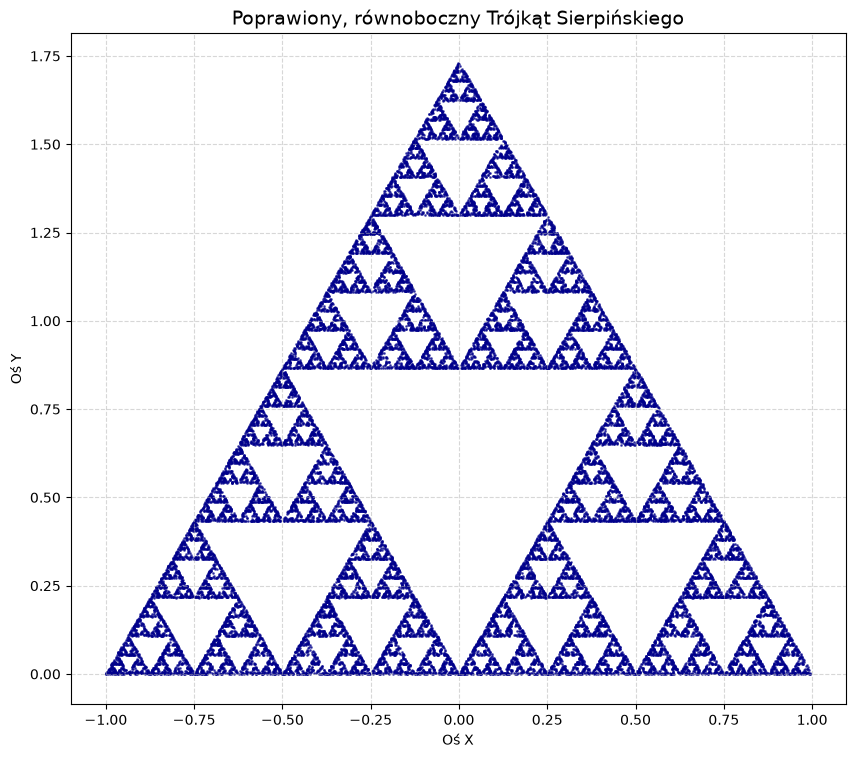

In [6]:
trojkat = np.loadtxt("trojkat.csv", delimiter=",")

# --- SPOSÓB Z UŻYCIEM WSPÓŁRZĘDNYCH JEDNORODNYCH ---
# Dodajemy kolumnę jedynek do naszych danych (wymiar 30000 x 3)
jedynki = np.ones((trojkat.shape[0], 1))
trojkat_hom = np.hstack([trojkat, jedynki])

# Definiujemy macierz przekształcenia (skalowanie + pochylenie + translacja)
M = np.array([[2, 0, 0], [1, np.sqrt(3), 0], [-1, 0, 1]])

# Mnożymy macierze
trojkat_transformowany_hom = trojkat_hom @ M

# Wyciągamy z powrotem tylko kolumny X i Y
trojkat_nowy = trojkat_transformowany_hom[:, :2]
fig, ax = plt.subplots(figsize=(10, 10))
plt.scatter(trojkat_nowy[:, 0], trojkat_nowy[:, 1],
            s=1, c="darkblue", alpha=0.6)

plt.gca().set_aspect("equal", adjustable="box")

plt.title("Poprawiony, równoboczny Trójkąt Sierpińskiego", fontsize=14)
plt.xlabel("Oś X")
plt.ylabel("Oś Y")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Zad 4
Celem zadania jest ortonormalizacja wektorów $u, v, w$ bezpośrednio ze wzorów rzutowania oraz zapisanie macierzy jako produkt $A = QR$.

## 1. Wzory jawne (Algorytm)

**Etap 1: Ortogonalizacja (wektory prostopadłe $v_i$):**
* $v_1 = u$
* $v_2 = v - \frac{\langle v, v_1 \rangle}{\|v_1\|^2} v_1$
* $v_3 = w - \frac{\langle w, v_1 \rangle}{\|v_1\|^2} v_1 - \frac{\langle w, v_2 \rangle}{\|v_2\|^2} v_2$

**Etap 2: Normalizacja (wektory jednostkowe $e_i$):**
* $e_i = \frac{v_i}{\|v_i\|}$

---


In [7]:
# 1. Definicja wektorów początkowych (kolumny macierzy A)
u = np.array([2, 0, 1], dtype=float)
v = np.array([-1, 2, -1], dtype=float)
w = np.array([3, -1, 2], dtype=float)

A = np.column_stack((u, v, w))

# --- KROK 1: ORTOGONALIZACJA (Wyznaczenie v1, v2, v3 ze wzorów) ---
v1 = u

# Wzór: v2 = v - ( <v, v1> / ||v1||^2 ) * v1
v2 = v - (np.dot(v, v1) / np.dot(v1, v1)) * v1

# Wzór: v3 = w - ( <w, v1> / ||v1||^2 ) * v1 - ( <w, v2> / ||v2||^2 ) * v2
v3 = w - (np.dot(w, v1) / np.dot(v1, v1)) * v1 - \
    (np.dot(w, v2) / np.dot(v2, v2)) * v2


# --- KROK 2: NORMALIZACJA (Wyznaczenie e1, e2, e3) ---
e1 = v1 / np.linalg.norm(v1)
e2 = v2 / np.linalg.norm(v2)
e3 = v3 / np.linalg.norm(v3)


# --- KROK 3: BUDOWA MACIERZY Q I R ---
# Macierz Q tworzą kolumny wektorów ortonormalnych
Q_reczne = np.column_stack((e1, e2, e3))

# Macierz R wyliczana z iloczynów skalarnych (górnotrójkątna)
R_reczne = np.array([
    [np.dot(u, e1), np.dot(v, e1), np.dot(w, e1)],
    [0,             np.dot(v, e2), np.dot(w, e2)],
    [0,             0,             np.dot(w, e3)]
])


# --- KROK 4: GOTOWA PROCEDURA NUMPY ---
Q_np, R_np = np.linalg.qr(A)


print("recznie")
print("Macierz Q:\n", np.round(Q_reczne, 4))
print("Macierz R:\n", np.round(R_reczne, 4))

print("\n numpy")
print("Macierz Q:\n", np.round(Q_np, 4))
print("Macierz R:\n", np.round(R_np, 4))

print("\nCzy iloczyn Q * R odtwarza macierz A?:",
      np.allclose(Q_reczne @ R_reczne, A))

recznie
Macierz Q:
 [[ 0.8944  0.0976 -0.4364]
 [ 0.      0.9759  0.2182]
 [ 0.4472 -0.1952  0.8729]]
Macierz R:
 [[ 2.2361 -1.3416  3.5777]
 [ 0.      2.0494 -1.0735]
 [ 0.      0.      0.2182]]

 numpy
Macierz Q:
 [[-0.8944 -0.0976 -0.4364]
 [-0.     -0.9759  0.2182]
 [-0.4472  0.1952  0.8729]]
Macierz R:
 [[-2.2361  1.3416 -3.5777]
 [ 0.     -2.0494  1.0735]
 [ 0.      0.      0.2182]]

Czy iloczyn Q * R odtwarza macierz A?: True


# Zad 5
# 1. Wartości własne i podprzestrzenie (Szukanie skali i kierunków).
Najpierw szukamy wartości własnych ($\lambda$),
 czyli współczynników, o które nasza macierz rozciąga lub ściska przestrzeń. Wyliczamy je z równania charakterystycznego $\det(A - \lambda I) = 0$.Następnie dla każdej znalezionej liczby $\lambda$ tworzymy układ równań $(A - \lambda I)X = 0$, który opisuje podprzestrzenie własne. To nic innego jak proste lub płaszczyzny w przestrzeni, które pod wpływem działania macierzy $A$ nie zmieniają swojego kierunku, a są jedynie skalowane (wydłużane/skracane) o wartość $\lambda$.

# 2. Diagonalizacja (Tworzenie bazy idealnej)
Z wektorów, które wyznaczają te niezmienne kierunki (wektorów własnych), budujemy macierz przejścia $P$. Same wartości $\lambda$ ustawiamy na głównej przekątnej nowej macierzy $D$ (diagonalnej).

# 3. Szybkie potęgowanie ($A^5$)
Za pomocą wzoru:
$$A^5 = (PDP^{-1}) \cdot (PDP^{-1}) \cdot (PDP^{-1}) \cdot (PDP^{-1}) \cdot (PDP^{-1})$$Wszystkie sąsiadujące ze sobą macierze $P^{-1}$ oraz $P$ mnożą się, dając macierz jednostkową ($P^{-1}P = I$), co oznacza, że po prostu się "kasują". Dzięki temu cały środek wyrażenia znika, a wzór skraca się do postaci:$$A^5 = P D^5 P^{-1}$$

In [8]:
# Definiujemy wektor zmiennych [x, y, z]^T do wypisania równań
x, y, z = sp.symbols('x y z')
X = sp.Matrix([x, y, z])

# Definiujemy macierz A
A = sp.Matrix([
    [1,  1, -2],
    [-1,  3, -2],
    [1, -1,  4]
])

print("Wartości własne")
eigenvals = A.eigenvals()
for val, krot in eigenvals.items():
    print(f"Wartość własna: lambda = {val} (krotność: {krot})")

print("\nRównania podprzestrzeni własnych")
I = sp.eye(3)  # Macierz jednostkowa 3x3
for lam in eigenvals.keys():
    print(f"\nDla lambda = {lam}:")
    # Rozwiązujemy (A - lambda * I) * X = 0
    eq_matrix = A - lam * I
    equations = eq_matrix * X
    print("Układ równań:")
    for eq in equations:
        print(f"  {eq} = 0")

print("\nDiagonalizacja macierzy A")
P, D = A.diagonalize()
print("Macierz przejścia P (wektory własne w kolumnach):")
sp.pprint(P)
print("\nMacierz diagonalna D (wartości własne na przekątnej):")
sp.pprint(D)

print("\nObliczenie A^5 za pomocą diagonalizacji")
# Obliczamy D^5 (potęgowanie elementów na przekątnej)
D5 = D**5
# A^5 = P * D^5 * P^-1
A5_diag = P * D5 * P.inv()

print("Macierz A^5:")
sp.pprint(A5_diag)

#sprawdzenie:
print(A5_diag == A**5)

Wartości własne
Wartość własna: lambda = 4 (krotność: 1)
Wartość własna: lambda = 2 (krotność: 2)

Równania podprzestrzeni własnych

Dla lambda = 4:
Układ równań:
  -3*x + y - 2*z = 0
  -x - y - 2*z = 0
  x - y = 0

Dla lambda = 2:
Układ równań:
  -x + y - 2*z = 0
  -x + y - 2*z = 0
  x - y + 2*z = 0

Diagonalizacja macierzy A
Macierz przejścia P (wektory własne w kolumnach):
⎡1  -2  -1⎤
⎢         ⎥
⎢1  0   -1⎥
⎢         ⎥
⎣0  1   1 ⎦

Macierz diagonalna D (wartości własne na przekątnej):
⎡2  0  0⎤
⎢       ⎥
⎢0  2  0⎥
⎢       ⎥
⎣0  0  4⎦

Obliczenie A^5 za pomocą diagonalizacji
Macierz A^5:
⎡-464  496   -992⎤
⎢                ⎥
⎢-496  528   -992⎥
⎢                ⎥
⎣496   -496  1024⎦
True


# Zad 6
Rozkład SVD polega na rozbiciu macierzy $A$ na trzy składowe: $A = U \Sigma V^T$


In [9]:
# Zwiększamy czytelność wydruku macierzy (mniej miejsc po przecinku)
np.set_printoptions(precision=4, suppress=True)

# 1. Definicja macierzy A
A = np.array([[2, 1],
              [2, 1]])

print("rozkład SVD")
print("Macierz A:\n", A)

# 2. Obliczamy A^T * A
ATA = A.T @ A

# 3. Szukamy wartości i wektorów własnych macierzy A^T * A
# Używamy funkcji eig, aby uzyskać lambdy i bazę wektorów
eigenvalues, eigenvectors = np.linalg.eig(ATA)

# Sortujemy wartości i wektory własne malejąco
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
V = eigenvectors[:, idx]

print("\nWartości własne (lambda):", eigenvalues)

# 4. Obliczamy wartości osobliwe (sigma) z pierwiastków lambd
# Odfiltrowujemy błędy numeryczne bliskie zeru
eigenvalues[eigenvalues < 1e-10] = 0
singular_values = np.sqrt(eigenvalues)

# Budujemy macierz diagonalną Sigma
Sigma = np.zeros_like(A, dtype=float)
np.fill_diagonal(Sigma, singular_values)
print("\nMacierz Sigma:\n", Sigma)
print("\nMacierz V:\n", V)

# 5. Budujemy macierz U z wektorów u_i
U = np.zeros_like(A, dtype=float)

for i in range(len(singular_values)):
    if singular_values[i] > 1e-10:
        # Wzór dla niezerowych wartości osobliwych: u_i = (1/sigma_i) * A * v_i
        v_i = V[:, i]
        U[:, i] = (1 / singular_values[i]) * (A @ v_i)
    else:
        # Dla sigma = 0 musimy znaleźć wektor ortogonalny do już wyznaczonego u1.
        # W przestrzeni 2D dla wektora [x, y], wektor prostopadły to np. [-y, x]
        u1 = U[:, 0]
        U[:, i] = np.array([-u1[1], u1[0]])

print("\nMacierz U:\n", U)

# Sprawdzenie: U * Sigma * V^T powinno dać oryginalną macierz A
A_rekonstrukcja = U @ Sigma @ V.T
print("\nSprawdzenie (U * Sigma * V^T):\n", A_rekonstrukcja)


print("\n\n pseudo invers")

# 1. Tworzymy macierz Sigma^+
# Transponujemy wymiary (tutaj kwadrat, więc bez zmian)
Sigma_plus = np.zeros_like(Sigma).T

for i in range(min(Sigma.shape)):
    if singular_values[i] > 1e-10:
        # Odwracamy tylko niezerowe elementy na przekątnej
        Sigma_plus[i, i] = 1 / singular_values[i]

print("Macierz Sigma^+:\n", Sigma_plus)

# 2. Obliczamy pseudoodwrotność wzorem: A^+ = V * Sigma^+ * U^T
A_plus = V @ Sigma_plus @ U.T

print("\nPseudoodwrotność (A^+):\n", A_plus)

# Oczekiwany wynik na podstawie ręcznych obliczeń to ułamki:
# [[0.2, 0.2],
#  [0.1, 0.1]]

rozkład SVD
Macierz A:
 [[2 1]
 [2 1]]

Wartości własne (lambda): [10.+0.j  0.+0.j]

Macierz Sigma:
 [[3.1623 0.    ]
 [0.     0.    ]]

Macierz V:
 [[ 0.8944+0.j -0.4472+0.j]
 [ 0.4472+0.j  0.8944+0.j]]

Macierz U:
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Sprawdzenie (U * Sigma * V^T):
 [[2.+0.j 1.+0.j]
 [2.+0.j 1.+0.j]]


 pseudo invers
Macierz Sigma^+:
 [[0.3162 0.    ]
 [0.     0.    ]]

Pseudoodwrotność (A^+):
 [[0.2+0.j 0.2+0.j]
 [0.1+0.j 0.1+0.j]]


/home/pkrzysiek/.local/lib/python3.14/site-packages/numpy/lib/_index_tricks_impl.py:923: ComplexWarning: Casting complex values to real discards the imaginary part
  a.flat[:end:step] = val
/tmp/ipykernel_14060/2472671847.py:43: ComplexWarning: Casting complex values to real discards the imaginary part
  U[:, i] = (1 / singular_values[i]) * (A @ v_i)
/tmp/ipykernel_14060/2472671847.py:66: ComplexWarning: Casting complex values to real discards the imaginary part
  Sigma_plus[i, i] = 1 / singular_values[i]


# Zad 7


In [10]:

# Definicja macierzy wejściowej
A = sp.Matrix([
    [2, 3, 1, 0],
    [0, 1, -1, 2],
    [3, 1, 1, 4]
])

# 1. Wyznaczenie rzędu macierzy
rzad = A.rank()

# 2. Obliczenie macierzy A * A^T oraz jej odwrotności
A_AT = A * A.T
A_AT_inv = A_AT.inv()

# 3. Wyznaczenie pseudoodwrotności ze wzoru: A^+ = A^T * (A * A^T)^(-1)
A_pinv = A.T * A_AT_inv

print("Macierz pseudoodwrotna A+:")
sp.pprint(A_pinv)

# 4. Sprawdzenie warunków Moore'a-Penrose'a
print("\nWeryfikacja warunków:")
print("Warunek 1 (A * A+ * A == A):", A * A_pinv * A == A)
print("Warunek 2 (A+ * A * A+ == A+):", A_pinv * A * A_pinv == A_pinv)
print("Warunek 3 ((A * A+)^T == A * A+):", (A * A_pinv).T == A * A_pinv)
print("Warunek 4 ((A+ * A)^T == A+ * A):", (A_pinv * A).T == A_pinv * A)

Macierz pseudoodwrotna A+:
⎡       -28    19  ⎤
⎢8/123  ────   ─── ⎥
⎢       123    123 ⎥
⎢                  ⎥
⎢ 23     11        ⎥
⎢ ──     ──   -6/41⎥
⎢ 82     41        ⎥
⎢                  ⎥
⎢       -43    16  ⎥
⎢7/246  ────   ─── ⎥
⎢       123    123 ⎥
⎢                  ⎥
⎢-31    47     17  ⎥
⎢────   ───    ─── ⎥
⎣246    246    123 ⎦

Weryfikacja warunków:
Warunek 1 (A * A+ * A == A): True
Warunek 2 (A+ * A * A+ == A+): True
Warunek 3 ((A * A+)^T == A * A+): True
Warunek 4 ((A+ * A)^T == A+ * A): True


# Zad 8
Do wykonania ćwiczenia wykorzystamy kompresję obrazu za pomocą SVD

Wymiary wczytanego obrazu: (1080, 1920, 3)
Format: (Wysokość, Szerokość, Liczba kanałów RGB)


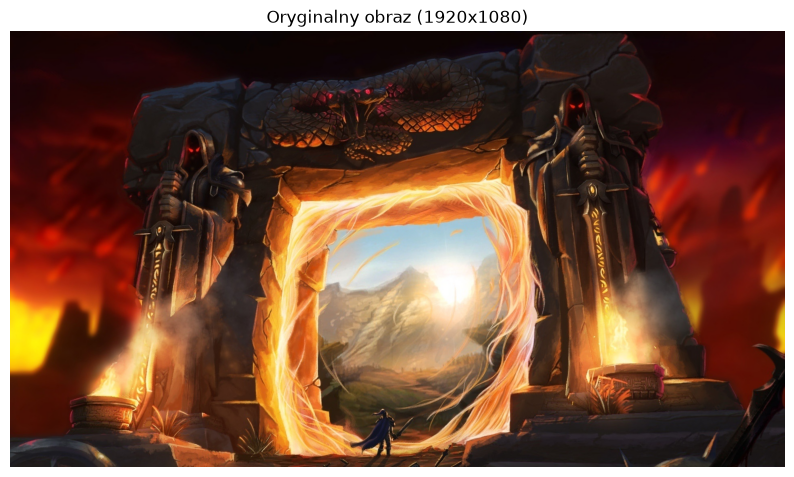

In [11]:
# Wczytanie oryginalnego obrazu
skladnik_img = Image.open('obrazek.jpg')
img_array = np.array(skladnik_img)

print(f"Wymiary wczytanego obrazu: {img_array.shape}")
print("Format: (Wysokość, Szerokość, Liczba kanałów RGB)")

# Wyświetlenie oryginału
plt.figure(figsize=(10, 6))
plt.imshow(img_array)
plt.title("Oryginalny obraz (1920x1080)")
plt.axis('off')
plt.show()


### Krok 2: Teoria SVD i definicja funkcji kompresującej
Każdą macierz dwuwymiarową (reprezentującą jeden kanał koloru: Czerwony, Zielony lub Niebieski) można zapisać jako iloczyn trzech macierzy:
$$A = U \Sigma V^T$$

Gdzie $\Sigma$ zawiera na głównej przekątnej wartości osobliwe (singular values) posortowane malejąco. Kompresja polega na ucięciu tego rozkładu do pierwszych $k$ wartości osobliwych (aproksymacja niskorangowa):
$$A_k = U_k \Sigma_k V_k^T$$

Ponieważ obraz jest kolorowy, algorytm SVD musimy wykonać niezależnie dla każdego z trzech kanałów (RGB), a następnie złożyć je z powrotem w jedną całość.

In [12]:
def kompresuj_kanal(kanal, k):
    # Wyznaczenie rozkładu SVD dla jednego kanału
    U, S, Vt = np.linalg.svd(kanal, full_matrices=False)

    # Rekonstrukcja macierzy przy użyciu tylko 'k' wartości osobliwych
    rekonstrukcja = np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))

    # Przycięcie wartości do poprawnego zakresu pikseli [0, 255]
    return np.clip(rekonstrukcja, 0, 255).astype(np.uint8)


def kompresja_svd_rgb(obraz_array, k):
    # Rozbicie na kanały R, G, B i kompresja każdego z nich
    r_komp = kompresuj_kanal(obraz_array[:, :, 0], k)
    g_komp = kompresuj_kanal(obraz_array[:, :, 1], k)
    b_komp = kompresuj_kanal(obraz_array[:, :, 2], k)

    # Złożenie skompresowanych kanałów w jeden obraz trójwymiarowy
    return np.stack([r_komp, g_komp, b_komp], axis=2)

### Krok 3: Wykonanie kompresji i zapis wyniku
Wybieramy liczbę $k$ wartości osobliwych (np. $k = 50$ z maksymalnie $1080$ dostępnych). Przeprowadzamy kompresję, a uzyskany rezultat zapisujemy na dysku jako nowy plik JPG.

In [13]:
# Liczba zachowanych wartości osobliwych 
k_wartosci = 50

# Uruchomienie kompresji
img_compressed_array = kompresja_svd_rgb(img_array, k_wartosci)

# Konwersja macierzy z powrotem na obiekt Image i zapis do pliku
skompresowany_img = Image.fromarray(img_compressed_array)
skompresowany_img.save('obrazek_skompresowany.jpg')

print(f"Kompresja zakończona sukcesem dla k = {k_wartosci}.")
print("Plik 'obrazek_skompresowany.jpg' został zapisany.")

Kompresja zakończona sukcesem dla k = 50.
Plik 'obrazek_skompresowany.jpg' został zapisany.


### Krok 4: Analiza stopnia podobieństwa do oryginału
Do matematycznej oceny jakości kompresji i "podobieństwa" obrazów wykorzystamy dwa standardowe wskaźniki macierzowe i sygnałowe:
1. **Błąd względny rekonstrukcji (oparty na normie Frobeniusa):** informuje nas, jaki procent informacji matematycznej został utracony.
2. **Błąd średniokwadratowy (MSE):** mierzy średnią kwadratów różnic między wartościami pikseli oryginału i kompresji.
3. **Szczytowy stosunek sygnału do szumu (PSNR):** wyrażany w decybelach (dB). Im wyższa wartość PSNR, tym obraz skompresowany jest bardziej zbliżony do oryginału (wartości powyżej 30 dB oznaczają zazwyczaj doskonałą jakość, słabo rozróżnialną okiem).

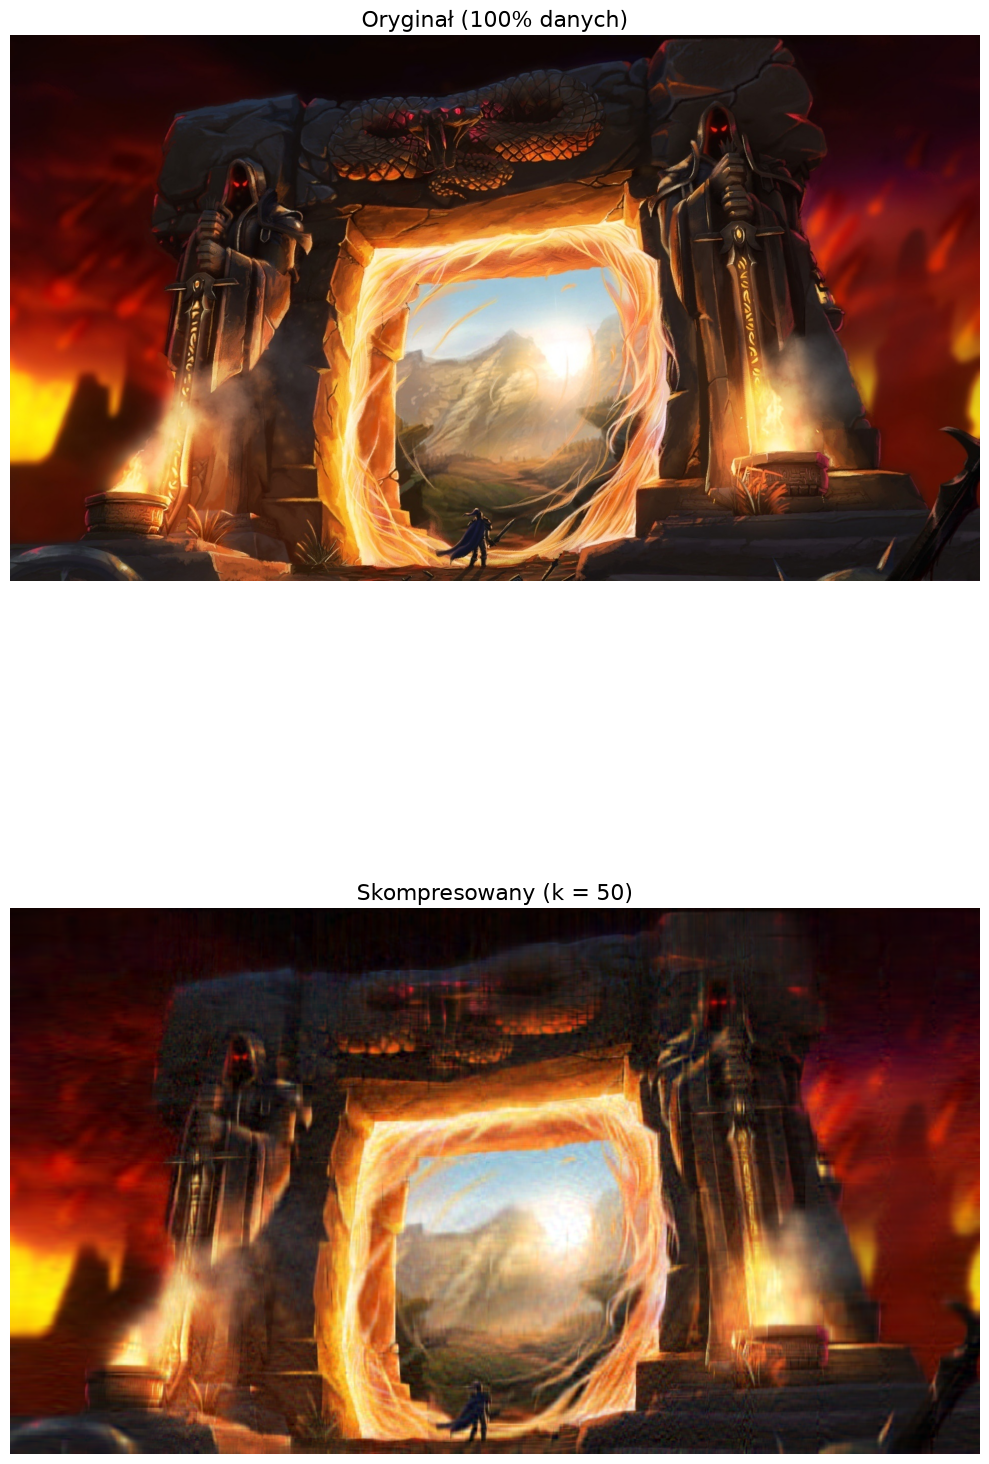

Błąd względny rekonstrukcji: 8.96 %
Podobieństwo matematyczne:   91.04 %
Błąd średniokwadratowy (MSE): 76.29
Wskaźnik jakości (PSNR):      29.31 dB


In [14]:
# Konwersja do typów zmiennoprzecinkowych na potrzeby obliczeń matematycznych
orig = img_array.astype(np.float64)
comp = img_compressed_array.astype(np.float64)

# 1. Obliczenie błędu względnego na podstawie normy Frobeniusa
norma_roznicy = np.linalg.norm(orig - comp)
norma_oryginalu = np.linalg.norm(orig)
blad_wzgledny = (norma_roznicy / norma_oryginalu) * 100

# 2. Obliczenie MSE
mse = np.mean((orig - comp) ** 2)

# 3. Obliczenie PSNR
if mse == 0:
    psnr = float('inf')
else:
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

fig, axes = plt.subplots(2, 1, figsize=(10, 20))
axes[0].imshow(img_array)
# Added larger font for readability
axes[0].set_title("Oryginał (100% danych)", fontsize=16)
axes[0].axis('off')

axes[1].imshow(img_compressed_array)
# Added larger font
axes[1].set_title(f"Skompresowany (k = {k_wartosci})", fontsize=16)
axes[1].axis('off')
plt.tight_layout()  # Added to prevent title overlap in vertical stacking
plt.show()

# Wyświetlenie raportu z analizy podobieństwa
print(f"Błąd względny rekonstrukcji: {blad_wzgledny:.2f} %")
print(f"Podobieństwo matematyczne:   {100 - blad_wzgledny:.2f} %")
print(f"Błąd średniokwadratowy (MSE): {mse:.2f}")
print(f"Wskaźnik jakości (PSNR):      {psnr:.2f} dB")

# Zad 9


In [15]:
df = pd.read_csv('measures.csv')

# Usunięcie wskazanej kolumny
df_cleaned = df.drop(columns=['brozek'])

# Konwersja na macierz NumPy
X_raw = df_cleaned.to_numpy()

print(f"Wymiary macierzy po usunięciu kolumny: {X_raw.shape}")
df_cleaned.head()
# Obliczenie średniej dla każdej kolumny
srednie = np.mean(X_raw, axis=0)

# Centrowanie danych
X_centered = X_raw - srednie
# Rozkład SVD dla scentrowanej macierzy
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Składowe główne (loadingi) z SVD
svd_components = Vt

# Nowe współrzędne danych (projekcja)
svd_scores = np.dot(X_centered, Vt.T)

# Obliczenie wyjaśnionej wariancji
n = X_raw.shape[0]
svd_variance = (S ** 2) / (n - 1)
svd_variance_ratio = svd_variance / np.sum(svd_variance)

Wymiary macierzy po usunięciu kolumny: (250, 5)


In [16]:
from sklearn.decomposition import PCA

# Inicjalizacja i dopasowanie modelu do surowych danych
pca = PCA()
sklearn_scores = pca.fit_transform(X_raw)

# Pobranie komponentów i wariancji z gotowej implementacji
sklearn_components = pca.components_
sklearn_variance = pca.explained_variance_
sklearn_variance_ratio = pca.explained_variance_ratio_

In [17]:
# 1. Sprawdzenie wariancji wyjaśnionej
print("CZY WARIANCJE SĄ IDENTYCZNE?")
print(f"SVD wariancje:  {svd_variance}")
print(f"Sklearn wariancje: {sklearn_variance}")
print(f"Zgodność wariancji: {np.allclose(svd_variance, sklearn_variance)}\n")

# 2. Sprawdzenie składowych głównych (komponentów) - porównanie modułów
komponenty_zgodne = np.allclose(
    np.abs(svd_components), np.abs(sklearn_components))
print("CZY SKŁADOWE GŁÓWNE SĄ IDENTYCZNE (co do modułu)?")
print(f"Wynik porównania: {komponenty_zgodne}\n")

# 3. Sprawdzenie zredukowanych współrzędnych (scores) - porównanie modułów
wspolrzedne_zgodne = np.allclose(np.abs(svd_scores), np.abs(sklearn_scores))
print("CZY WSPÓŁRZĘDNE PUNKTÓW PO TRANSFORMACJI SĄ IDENTYCZNE (co do modułu)?")
print(f"Wynik porównania: {wspolrzedne_zgodne}\n")

# Podsumowanie procentowe wariancji
print("PROCENT WYJAŚNIONEJ WARIANCJI DLA KOLEJNYCH SKŁADOWYCH:")
for i, prop in enumerate(svd_variance_ratio):
    print(f"PC{i+1}: {prop*100:.2f}%")

CZY WARIANCJE SĄ IDENTYCZNE?
SVD wariancje:  [869.7918 169.5495  19.9436   6.9825   2.2516]
Sklearn wariancje: [869.7918 169.5495  19.9436   6.9825   2.2516]
Zgodność wariancji: True

CZY SKŁADOWE GŁÓWNE SĄ IDENTYCZNE (co do modułu)?
Wynik porównania: True

CZY WSPÓŁRZĘDNE PUNKTÓW PO TRANSFORMACJI SĄ IDENTYCZNE (co do modułu)?
Wynik porównania: True

PROCENT WYJAŚNIONEJ WARIANCJI DLA KOLEJNYCH SKŁADOWYCH:
PC1: 81.40%
PC2: 15.87%
PC3: 1.87%
PC4: 0.65%
PC5: 0.21%
